# 1. Introduction and Problem Statement.

**Introduction**
- we are working on the beginner titanic dataset which always has some hidden insights yet to be explored.
- I will be performing basic Exploratory Data Analysis with Feature Engineering and handling missing values.
- Not going to implement Machine Learning Algorithms or other deep statistical Algorithms as of now.

 **Problem Statement:**

 Handle major part of missing values and perform feature enginnerring on columns to create a File ready to be fed in ML model and to get deep insights about the survival of passengers.

# 2. Import libraries  

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Load Dataset

In [3]:
titanic_dataset = pd.read_csv('train.csv')

# 4. Data Overview
- Contains the passengers detail of The infamous Titanic (1912), whether they survived or not.


In [4]:
titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic_dataset.shape

(891, 12)

In [6]:
titanic_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
titanic_dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic_dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 5. Univariate analysis on numerical column

## 5.1 Age

**conclusions**

- Age is normally(almost) distributed
- 20% of the values are missing
- There are some outliers, but they can help in survival prediction.

In [9]:
titanic_dataset['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
titanic_dataset['Age'].describe()  #descriptive analysis: 25percentile (Q1) means 25% passenger have age less than 20.125

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

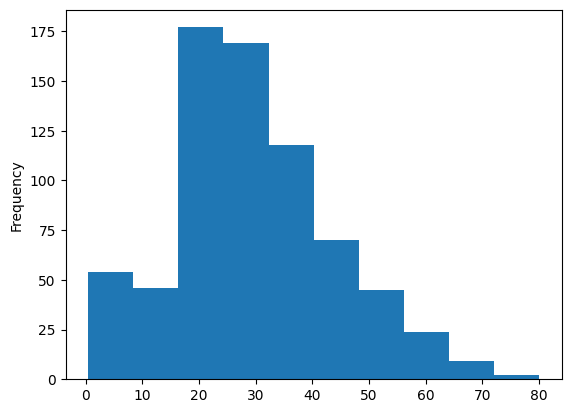

In [11]:
titanic_dataset['Age'].plot(kind='hist',bins=10)

<Axes: ylabel='Density'>

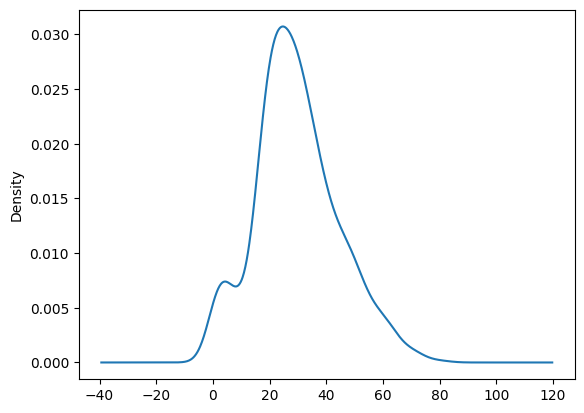

In [12]:
titanic_dataset['Age'].plot(kind='kde') # we get destribution of the data

In [13]:
titanic_dataset['Age'].skew()

np.float64(0.38910778230082704)

<Axes: >

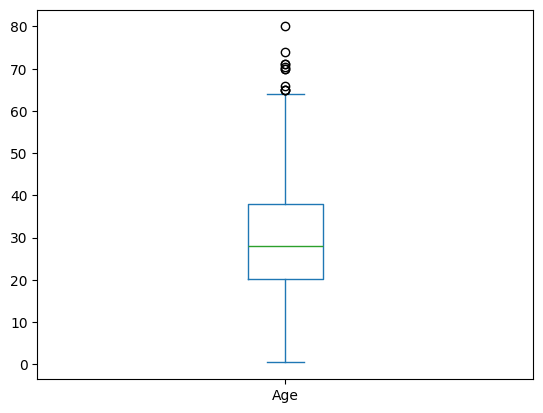

In [14]:
titanic_dataset['Age'].plot(kind='box')

In [15]:
titanic_dataset[titanic_dataset['Age'] > 65] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [16]:
titanic_dataset['Age'].isnull().sum()/len(titanic_dataset['Age'])   #19 % passengers have missing value

np.float64(0.19865319865319866)

## 5.2 Fare

**conclusions**

- The data is highly(positively) skewed
- Fare col actually contains the group fare and not the individual fare(This migth be an issue)
- We need to create a new col called individual fare (feature engineer)

In [17]:
titanic_dataset['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

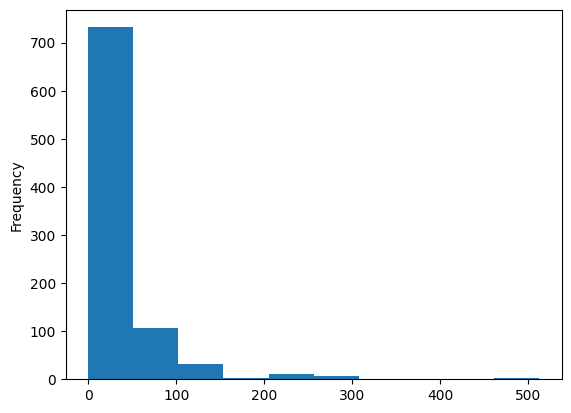

In [18]:
titanic_dataset['Fare'].plot(kind='hist') 

<Axes: ylabel='Density'>

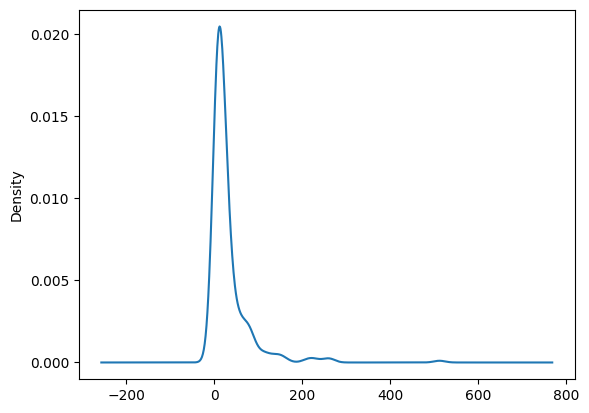

In [19]:
titanic_dataset['Fare'].plot(kind='kde') #not normally distributed

In [20]:
titanic_dataset['Fare'].skew() #highly positive skewed data

np.float64(4.787316519674893)

<Axes: >

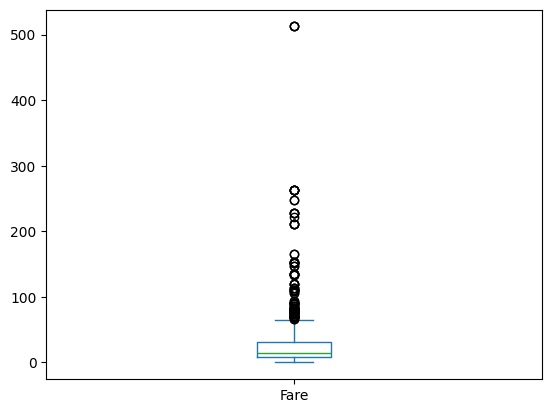

In [21]:
titanic_dataset['Fare'].plot(kind='box')

In [22]:
titanic_dataset[titanic_dataset['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [23]:
titanic_dataset['Fare'].isnull().sum()

np.int64(0)

# 6. Univariate Analysis on Categorical columns


## 6.1 Categorical cols

**conclusions**

- Parch and SibSp cols can be merged to form  a new col call family_size then giving us Family_type.
- Embarked has 2 missing values and need to be filled, majority passengers embarked from Southampton.
- Passenger class majority travelled in 3rd then 1st then 2nd, which is unnatural.
- Cabin can help in extracting the Deck position of passengers.

In [24]:
titanic_dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [25]:
# we can do this to all categorical col to get analysis
titanic_dataset['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

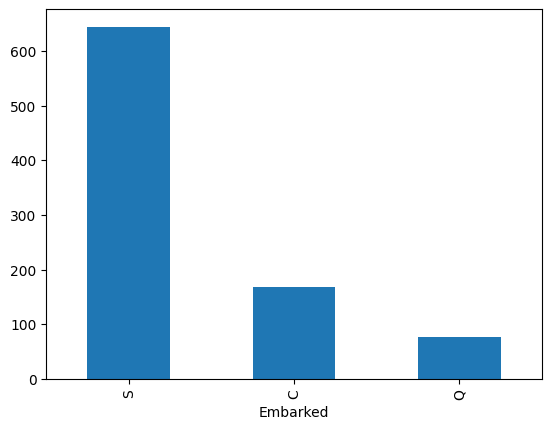

In [26]:
titanic_dataset['Embarked'].value_counts().plot(kind='bar')

<Axes: >

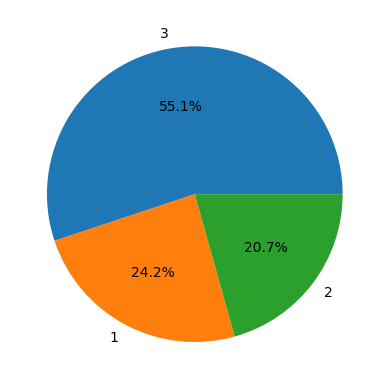

In [27]:
titanic_dataset['Pclass'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [28]:
titanic_dataset['Sex'].isnull().sum()

np.int64(0)

## 6.2 Mixed cols

**conclusion**
- need to do feature enginnering on mixed cols to get some analysis

# 7. Feature Enginneering
- Fare was give the total amount paid by the family, need a new column with individual fare paid.
- Sibling, spouse, parents, child are given seprately. They can be combined together to create family size and family type.
- Titles can be extracted from names of passengers.
- Deck can be extracted from Cabin number and missing values can be filled with a dummy variable 'M'.

## 7.1 Fare column

In [29]:
titanic_dataset['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [30]:
titanic_dataset[titanic_dataset['SibSp']==8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [31]:
titanic_dataset[titanic_dataset['Ticket'] == 'CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [32]:
titanic_dataset[titanic_dataset['Name'].str.contains('Sage')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.30,B35,C
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [33]:
test_titanic_df = pd.read_csv('test.csv')

In [34]:
merged_data = pd.concat([titanic_dataset,test_titanic_df])

In [35]:
merged_data.to_csv('concated.csv', index=False)

In [36]:
merged_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [37]:
merged_data[merged_data['Ticket'] == 'CA 2144']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
59,60,0.0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S
71,72,0.0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S
386,387,0.0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S
480,481,0.0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S
678,679,0.0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S
683,684,0.0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,NaN,S
139,1031,NaN,3,"Goodwin, Mr. Charles Frederick",male,40.0,1,6,CA 2144,46.9,NaN,S
140,1032,NaN,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9,NaN,S


In [38]:
merged_data['individual_fare'] = merged_data['Fare']/(merged_data['SibSp'] + merged_data['Parch'] + 1)

<Axes: >

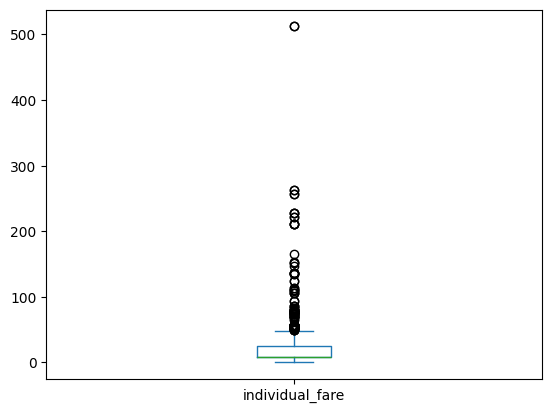

In [39]:
merged_data['individual_fare'].plot(kind='box')

In [40]:
merged_data[['individual_fare','Fare']].describe()


,individual_fare,Fare
count,1308.000000,1308.000000
mean,20.518215,33.295479
std,35.774337,51.758668
min,0.000000,0.000000
25%,7.452767,7.895800
50%,8.512483,14.454200
75%,24.237500,31.275000
max,512.329200,512.329200


In [41]:
merged_data[merged_data['Fare'] > 300]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare
258,259,1.0,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,512.3292
679,680,1.0,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,256.1646
737,738,1.0,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,512.3292
343,1235,NaN,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,256.1646


## 7.2 SibSp parch column

In [42]:
merged_data['family_size'] = merged_data['SibSp'] + merged_data['Parch'] + 1

In [43]:
merged_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1


In [44]:
# family_type
# 1 -> alone
# 2-4 -> small
# >5 -> large

def transform_family_size(num):

  if num == 1:
    return 'alone'
  elif num>1 and num <5:
    return "small"
  else:
    return "large"

In [45]:
merged_data['family_type'] = merged_data['family_size'].apply(transform_family_size)

In [46]:
merged_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2,small
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2,small
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1,alone


## 7.3 Titles

In [47]:
merged_data['surname'] = merged_data['Name'].str.split(',').str.get(0)

In [48]:
merged_data['Name'].str.strip()
merged_data['Title'] = merged_data['Name'].str.split(',').str.get(1).str.split(' ').str.get(1)
merged_data['Title'].value_counts()

Title
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Ms.            2
Major.         2
Mlle.          2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [49]:
merged_data['Title'] = merged_data['Title'].replace(['Rev.','Dr.','Col.','Major.','Don.','Sir.','Capt.','the','Jonkheer.'],'other')
merged_data['Title'] = merged_data['Title'].replace(['Mlle.','Ms.'],'Miss.')
merged_data['Title'] = merged_data['Title'].replace(['Dona.','Mme.','Lady.'],'Mrs.')

merged_data['Title'].value_counts()

Title
Mr.        757
Miss.      264
Mrs.       200
Master.     61
other       27
Name: count, dtype: int64

In [50]:
merged_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small,Braund,Mr.
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2,small,Cumings,Mrs.
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone,Heikkinen,Miss.
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2,small,Futrelle,Mrs.
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1,alone,Allen,Mr.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone,Spector,Mr.
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone,Oliva y Ocana,Mrs.
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone,Saether,Mr.
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1,alone,Ware,Mr.


## 7.4 Deck

In [51]:
merged_data['Deck'] = merged_data['Cabin'].str.strip().str.get(0)

# 8. Handling missing values
- Age missing values can be replaced with mean age of passengers based on the class they are travelling.
- Fare has only missing value no need for extra efforts and can be filled with mean fare.
- Cabin and Deck has about 70% of missing vslues which can be assigned a dummy variable 'M'.
- Embarked has 2 missing values, based on data Southamton has highest passenger embarking. So filling it with 'S'.
- Calculation error in Individual fare column which can be filleed easily.

In [52]:
merged_data.isna().sum()

PassengerId           0
Survived            418
Pclass                0
Name                  0
Sex                   0
Age                 263
SibSp                 0
Parch                 0
Ticket                0
Fare                  1
Cabin              1014
Embarked              2
individual_fare       1
family_size           0
family_type           0
surname               0
Title                 0
Deck               1014
dtype: int64

## 8.1 Age

In [53]:
merged_data['Pclass'].value_counts()

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [54]:
merged_data['Age'].mean()

np.float64(29.881137667304014)

In [55]:
merged_data[merged_data['Pclass']==1]['Age'].mean()

np.float64(39.15992957746479)

In [56]:
merged_data[merged_data['Pclass']==1]['Age'].isna().value_counts()

Age
False    284
True      39
Name: count, dtype: int64

In [57]:
merged_data.loc[merged_data['Pclass'] == 1, 'Age'] = merged_data.loc[merged_data['Pclass'] == 1, 'Age'].fillna(merged_data[merged_data['Pclass']==1]['Age'].mean())

In [58]:
merged_data[merged_data['Pclass']==1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname,Title,Deck
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small,Cumings,Mrs.,C
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small,Futrelle,Mrs.,C
6,7,0.0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,51.86250,1,alone,McCarthy,Mr.,E
11,12,1.0,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,26.55000,1,alone,Bonnell,Miss.,C
23,24,1.0,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S,35.50000,1,alone,Sloper,Mr.,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,1295,NaN,1,"Carrau, Mr. Jose Pedro",male,17.0,0,0,113059,47.1000,NaN,S,47.10000,1,alone,Carrau,Mr.,NaN
404,1296,NaN,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,17765,27.7208,D40,C,13.86040,2,small,Frauenthal,Mr.,D
407,1299,NaN,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C,70.50000,3,small,Widener,Mr.,C
411,1303,NaN,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,45.00000,2,small,Minahan,Mrs.,C


In [59]:
merged_data[merged_data['Pclass']==2]['Age'].mean()

np.float64(29.506704980842912)

In [60]:
merged_data[merged_data['Pclass']==2]['Age'].isna().value_counts()

Age
False    261
True      16
Name: count, dtype: int64

In [61]:
merged_data.loc[merged_data['Pclass'] == 2, 'Age'] = merged_data.loc[merged_data['Pclass'] == 2, 'Age'].fillna(merged_data[merged_data['Pclass']==2]['Age'].mean())

In [62]:
merged_data[merged_data['Pclass']==3]['Age'].mean()

np.float64(24.81636726546906)

In [63]:
merged_data[merged_data['Pclass']==3]['Age'].isna().value_counts() #highest missing values in 3rd class

Age
False    501
True     208
Name: count, dtype: int64

In [64]:
merged_data.loc[merged_data['Pclass'] == 3, 'Age'] = merged_data.loc[merged_data['Pclass'] == 3, 'Age'].fillna(merged_data[merged_data['Pclass']==3]['Age'].mean())

## 8.2 Fare
- fare has only 1 missing value so we can simply replace it using median of Fares

In [65]:

merged_data['Fare'] = merged_data['Fare'].fillna(merged_data['Fare'].median())

In [66]:
merged_data.reset_index()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname,Title,Deck
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small,Braund,Mr.,NaN
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,35.641650,2,small,Cumings,Mrs.,C
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone,Heikkinen,Miss.,NaN
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,26.550000,2,small,Futrelle,Mrs.,C
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,8.050000,1,alone,Allen,Mr.,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,413,1305,NaN,3,"Spector, Mr. Woolf",male,24.816367,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone,Spector,Mr.,NaN
1305,414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone,Oliva y Ocana,Mrs.,C
1306,415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone,Saether,Mr.,NaN
1307,416,1308,NaN,3,"Ware, Mr. Frederick",male,24.816367,0,0,359309,8.0500,NaN,S,8.050000,1,alone,Ware,Mr.,NaN


In [67]:
merged_data.isna().sum()

PassengerId           0
Survived            418
Pclass                0
Name                  0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
Cabin              1014
Embarked              2
individual_fare       1
family_size           0
family_type           0
surname               0
Title                 0
Deck               1014
dtype: int64

## 8.3 Cabin and Deck

In [68]:
merged_data[merged_data['Cabin'].isnull()].shape[0]/len(merged_data['Cabin'])*100  #77% missing values

77.46371275783041

In [69]:
merged_data['Cabin'] = merged_data['Cabin'].fillna('M')


In [70]:
merged_data['Deck'] = merged_data['Deck'].fillna('M')

In [71]:
merged_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname,Title,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,M,S,3.625000,2,small,Braund,Mr.,M
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,35.641650,2,small,Cumings,Mrs.,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,M,S,7.925000,1,alone,Heikkinen,Miss.,M
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,26.550000,2,small,Futrelle,Mrs.,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,M,S,8.050000,1,alone,Allen,Mr.,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,24.816367,0,0,A.5. 3236,8.0500,M,S,8.050000,1,alone,Spector,Mr.,M
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone,Oliva y Ocana,Mrs.,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,M,S,7.250000,1,alone,Saether,Mr.,M
416,1308,NaN,3,"Ware, Mr. Frederick",male,24.816367,0,0,359309,8.0500,M,S,8.050000,1,alone,Ware,Mr.,M


## 8.4 Embarked

In [72]:
merged_data['Embarked'].value_counts()

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [73]:
merged_data['Embarked'] = merged_data['Embarked'].fillna('S') #since roughly 72% passengers embarked from Southampton

In [74]:
merged_data.isna().sum()

PassengerId          0
Survived           418
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin                0
Embarked             0
individual_fare      1
family_size          0
family_type          0
surname              0
Title                0
Deck                 0
dtype: int64

## 8.5 Individual Fare

In [75]:
merged_data['individual_fare'].isna().sum()

np.int64(1)

In [76]:
merged_data[merged_data['individual_fare'].isna()]['Fare']

152    14.4542
Name: Fare, dtype: float64

In [77]:
merged_data['individual_fare'] = merged_data['individual_fare'].fillna(merged_data[merged_data['individual_fare'].isna()]['Fare'])

In [78]:
merged_data.isna().sum()

PassengerId          0
Survived           418
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin                0
Embarked             0
individual_fare      0
family_size          0
family_type          0
surname              0
Title                0
Deck                 0
dtype: int64

In [79]:
merged_data.to_csv('merged_data_df.csv')

# 9. Bivariate Analysis
        
- Survival chances are directly proportional to Higher class.
- Survival chances of a females were significantly better than males.
- Higher passengers survived who embarked from Cherbourg in comparison to other to station, because 50% people travelled in 1st class from Cherbourg where 46% of them being females.
- 
- Survival chances of small family were higher than passengers travelling alone or with large family.
- Titles gives the same information as sex.

## 9.1 Survived and others

<Axes: xlabel='Pclass', ylabel='Survived'>

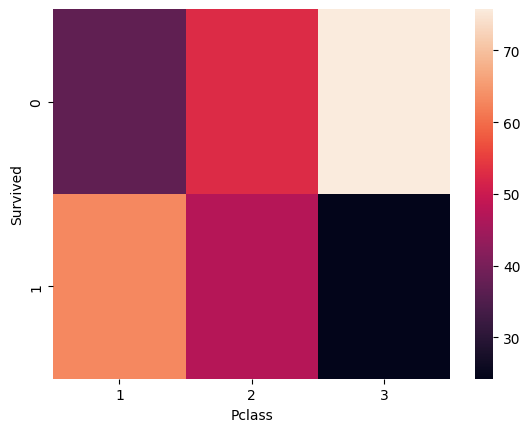

In [80]:
#Survived vs Classes
sns.heatmap(pd.crosstab(titanic_dataset['Survived'],titanic_dataset['Pclass'],normalize='columns')*100)

In [81]:
#Survived vs Sex
pd.crosstab(titanic_dataset['Survived'],titanic_dataset['Sex'],normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [82]:
#Survived and Embarked
pd.crosstab(titanic_dataset['Survived'],titanic_dataset['Embarked'],normalize='columns')*100 # why C people survived more??.. Maybe more females embarked from C or More rich P1 class people


Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [83]:
pd.crosstab(titanic_dataset['Sex'],titanic_dataset['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [84]:
pd.crosstab(titanic_dataset['Pclass'],titanic_dataset['Embarked'],normalize='columns')*100  # so this is the reason why C people survived more than Q and S

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


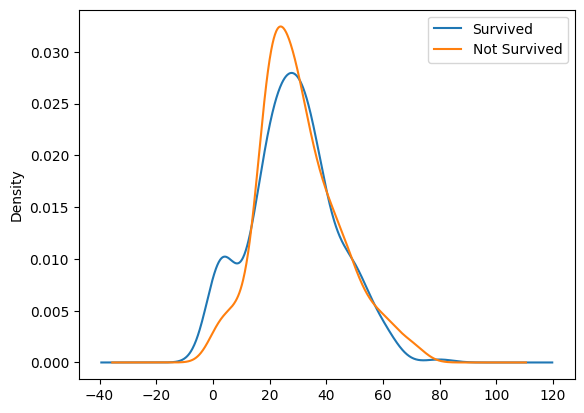

In [85]:
# Survived and Age
titanic_dataset[titanic_dataset['Survived'] == 1]['Age'].plot(kind='kde',label='Survived')
titanic_dataset[titanic_dataset['Survived'] == 0]['Age'].plot(kind='kde',label='Not Survived')

plt.legend()
plt.show()

## 9.2 Survived and Family_type

In [86]:
merged_data.reset_index(drop=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname,Title,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,M,S,3.625000,2,small,Braund,Mr.,M
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,35.641650,2,small,Cumings,Mrs.,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,M,S,7.925000,1,alone,Heikkinen,Miss.,M
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,26.550000,2,small,Futrelle,Mrs.,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,M,S,8.050000,1,alone,Allen,Mr.,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,24.816367,0,0,A.5. 3236,8.0500,M,S,8.050000,1,alone,Spector,Mr.,M
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone,Oliva y Ocana,Mrs.,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,M,S,7.250000,1,alone,Saether,Mr.,M
1307,1308,NaN,3,"Ware, Mr. Frederick",male,24.816367,0,0,359309,8.0500,M,S,8.050000,1,alone,Ware,Mr.,M


In [87]:

pd.crosstab(merged_data['Survived'].values,merged_data['family_type'].values,normalize='columns')*100

col_0,alone,large,small
row_0,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


In [88]:
merged_data[merged_data['Pclass']==1]['family_type'].value_counts()

family_type
alone    160
small    152
large     11
Name: count, dtype: int64

In [89]:
#Survived vs Titles
pd.crosstab(merged_data['Survived'].values,merged_data['Title'].values,normalize='columns')*100

col_0,Master.,Miss.,Mr.,Mrs.,other
row_0,,,,,
0.0,42.5,29.72973,84.332689,20.472441,68.181818
1.0,57.5,70.27027,15.667311,79.527559,31.818182


In [90]:
pd.crosstab(merged_data['Deck'].values,merged_data['Pclass'].values)

col_0,1,2,3
row_0,,,
A,22,0,0
B,65,0,0
C,94,0,0
D,40,6,0
E,34,4,3
F,0,13,8
G,0,0,5
M,67,254,693
T,1,0,0


<Axes: xlabel='row_0'>

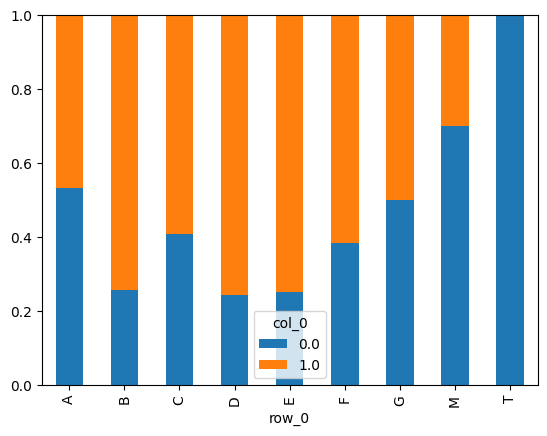

In [91]:
pd.crosstab(merged_data['Deck'].values,merged_data['Survived'].values,normalize='index').plot(kind='bar',stacked=True)

# 10. Multivariate analysis

In [92]:
dff = merged_data.drop(columns=['PassengerId','Name','SibSp','Parch','Cabin','Fare','Ticket'])
dff = dff.reset_index()
dff = dff.drop(columns=['index'])

In [93]:
dff

,Survived,Pclass,Sex,Age,Embarked,individual_fare,family_size,family_type,surname,Title,Deck
0,0.0,3,male,22.000000,S,3.625000,2,small,Braund,Mr.,M
1,1.0,1,female,38.000000,C,35.641650,2,small,Cumings,Mrs.,C
2,1.0,3,female,26.000000,S,7.925000,1,alone,Heikkinen,Miss.,M
3,1.0,1,female,35.000000,S,26.550000,2,small,Futrelle,Mrs.,C
4,0.0,3,male,35.000000,S,8.050000,1,alone,Allen,Mr.,M
...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,3,male,24.816367,S,8.050000,1,alone,Spector,Mr.,M
1305,NaN,1,female,39.000000,C,108.900000,1,alone,Oliva y Ocana,Mrs.,C
1306,NaN,3,male,38.500000,S,7.250000,1,alone,Saether,Mr.,M
1307,NaN,3,male,24.816367,S,8.050000,1,alone,Ware,Mr.,M


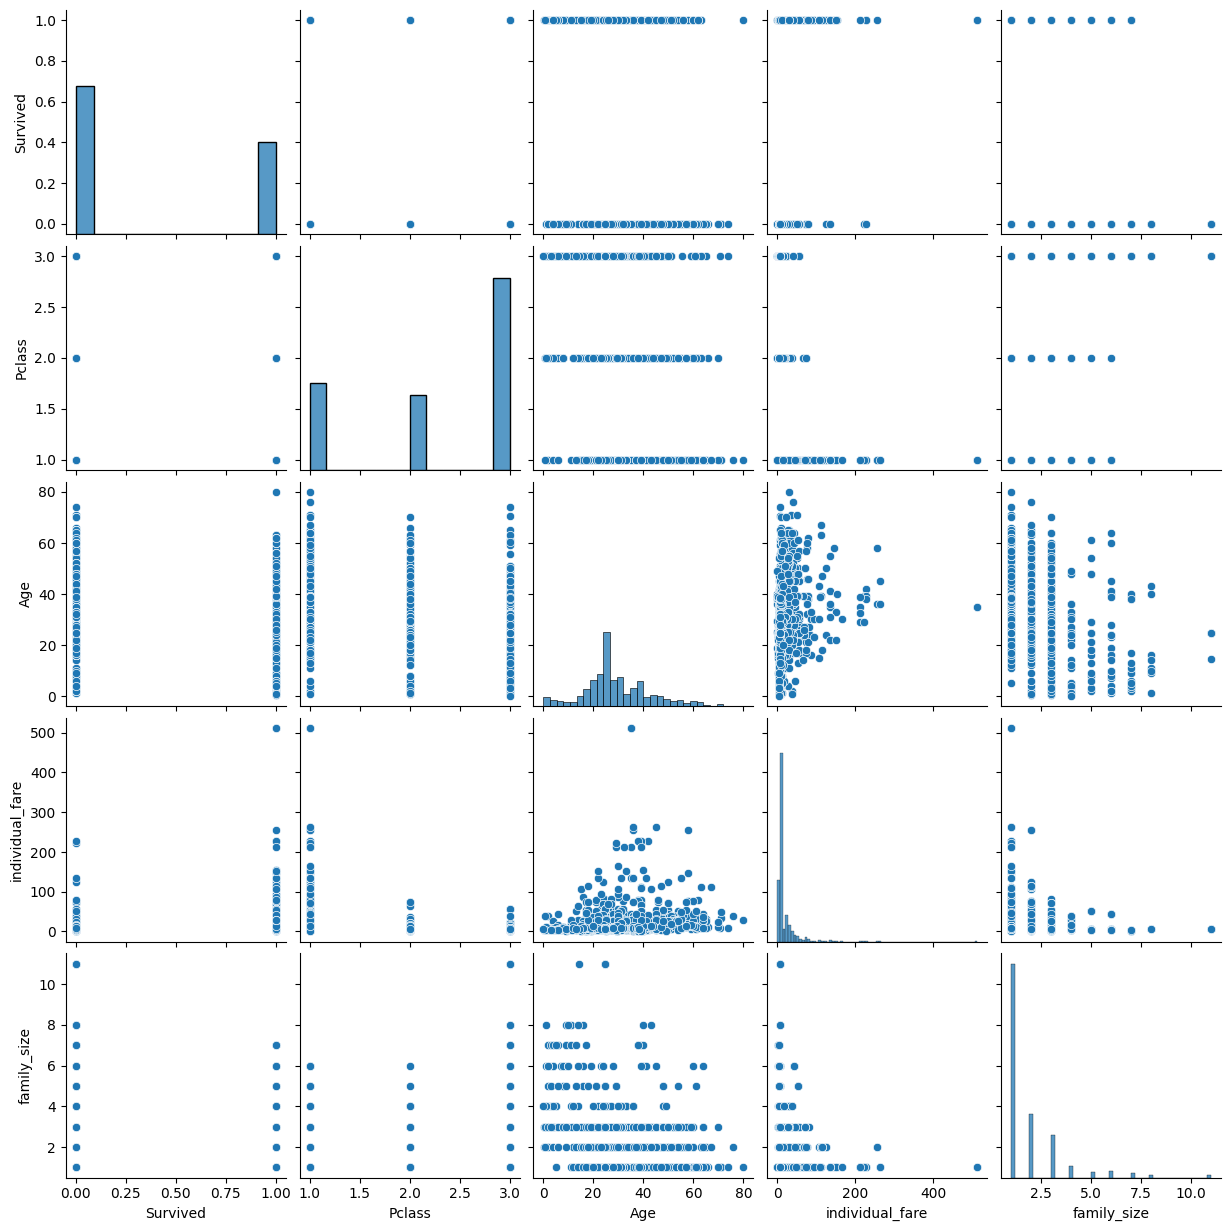

In [94]:
sns.pairplot(dff)

# 11. Conclusions and Insights
- Decided to keep the outliers(in Fare and Age). Since Fare and Age has deep correlation with survival